<a href="https://colab.research.google.com/github/anyakdard/ocean-acoustics/blob/main/02_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# run this before each session

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio

!pip install awscli



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


FileNotFoundError: [Errno 2] No such file or directory: '/content/orcadata/test.tsv'

In [7]:
# colab erases memory between sessions so need to redownload the files

!aws s3 cp s3://acoustic-sandbox/labeled-data/detection/train/TestDataLatest_PodCastAllRounds_123.tar.gz /content/orcadata.tar.gz --no-sign-request
!mkdir -p /content/orcadata
!tar -xzf /content/orcadata.tar.gz -C /content/orcadata
print('Data ready!')

download: s3://acoustic-sandbox/labeled-data/detection/train/TestDataLatest_PodCastAllRounds_123.tar.gz to ./orcadata.tar.gz
Data ready!


In [8]:
# Load the labels
df = pd.read_csv('/content/orcadata/test.tsv', sep='\t')
print('Labels loaded:', len(df), 'rows')

# Check the wav files are there
print('Wav files:', os.listdir('/content/orcadata/wav'))

Labels loaded: 828 rows
Wav files: ['streaming-orcasound-net_2019_11_14_13_02_00.wav', 'streaming-orcasound-net_2019_11_14_13_20_00.wav', 'streaming-orcasound-net_2019_11_14_13_27_00.wav', 'streaming-orcasound-net_2019_11_14_13_30_00.wav', 'OS_9_27_2017_08_25_00__0003.wav', 'streaming-orcasound-net_2019_11_14_13_55_00.wav', 'streaming-orcasound-net_2019_11_14_13_21_00.wav', 'streaming-orcasound-net_2019_11_14_13_49_00.wav', 'streaming-orcasound-net_2019_11_14_12_56_00.wav', 'streaming-orcasound-net_2019_11_14_12_50_00.wav', 'streaming-orcasound-net_2019_11_14_14_00_00.wav', 'OS_9_27_2017_11_32_00__0003.wav', 'streaming-orcasound-net_2019_11_14_13_16_00.wav', 'OS_9_27_2017_11_00_00__0004.wav', 'streaming-orcasound-net_2019_11_14_13_35_00.wav', 'streaming-orcasound-net_2019_11_14_13_34_00.wav', 'rpi-port-townsend_2019_11_14_14_11_00.wav', 'OS_9_27_2017_08_30_00__0003.wav', 'streaming-orcasound-net_2019_11_14_13_22_00.wav', 'streaming-orcasound-net_2019_11_14_13_29_00.wav', 'streaming-orc

In [9]:
# Create a folder to store spectrogram images
# exist_ok=True means don't error if it already exists
os.makedirs('/content/spectrograms/orca', exist_ok=True)

print('Output folder ready')

Output folder ready


In [10]:
# core of data pipeline
# loops through every labelled call and saves a mel spectrogram image

failed = []
# failed is an empty list we'll use to track any calls that don't process correctly

for i, row in df.iterrows():
    # df.iterrows() loops through the dataframe one row at a time
    # i is the row number, row is the actual data

    wav_path = f'/content/orcadata/wav/{row["wav_filename"]}'

    # Skip if the wav file doesn't exist
    if not os.path.exists(wav_path):
        failed.append(i)
        continue
    # continue means "skip the rest of this loop iteration and move to the next row"

    try:
        # Load just the call using its timestamp
        y_snippet, sr_snippet = librosa.load(wav_path,
                                              offset=row['start_time_s'],
                                              duration=row['duration_s'])

        # Generate mel spectrogram
        M = librosa.feature.melspectrogram(y=y_snippet, sr=sr_snippet)
        M_db = librosa.amplitude_to_db(M, ref=np.max)

        # Save as image
        # turn off axes/labels so the image is just the raw spectrogram
        fig, ax = plt.subplots(figsize=(2, 2))
        librosa.display.specshow(M_db, sr=sr_snippet, ax=ax)
        ax.axis('off')
        # axis('off') removes the tick marks and labels - want clean images for the classifier

        # Save with the row number as filename so we can trace it back to the label
        plt.savefig(f'/content/spectrograms/orca/call_{i:04d}.png',
                    bbox_inches='tight', pad_inches=0)
        # :04d formats the number with leading zeros e.g. 0001, 0042, 0828
        # bbox_inches='tight' and pad_inches=0 remove whitespace around the image
        plt.close()
        # close() frees up memory - important in a loop this size

    except Exception as e:
        # If anything goes wrong with this call, record it and keep going
        failed.append(i)

print(f'Done! Saved {828 - len(failed)} spectrograms')
print(f'Failed: {len(failed)} calls')

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(


Done! Saved 828 spectrograms
Failed: 0 calls


In [11]:
# Count how many images were saved
saved_files = os.listdir('/content/spectrograms/orca')
print(f'Images saved: {len(saved_files)}')

# Look at the first few filenames
print(saved_files[:5])

Images saved: 828
['call_0648.png', 'call_0379.png', 'call_0470.png', 'call_0176.png', 'call_0285.png']


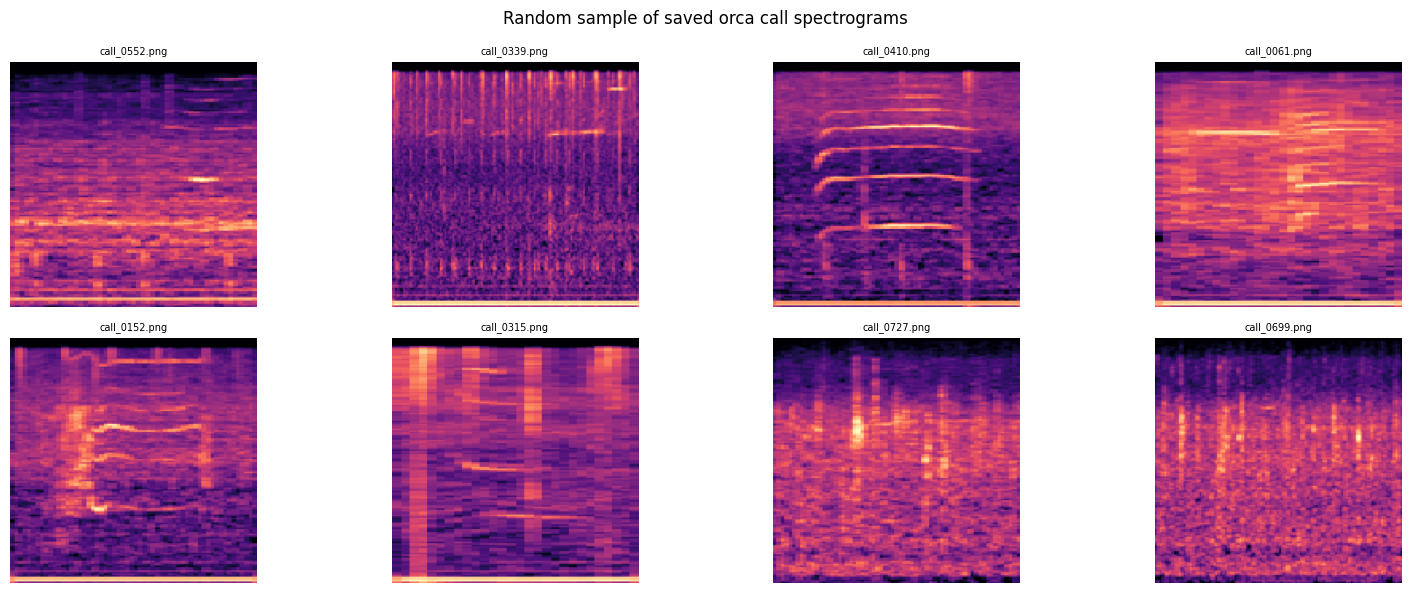

In [12]:
from matplotlib.image import imread
# imread loads an image file as an array of pixel values

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
# 2 rows, 4 columns = 8 random spectrograms to spot check
axes = axes.flatten()

import random
sample_files = random.sample(saved_files, 8)
# random.sample picks 8 random files from our list without repeating

for i, fname in enumerate(sample_files):
    img = imread(f'/content/spectrograms/orca/{fname}')
    axes[i].imshow(img)
    axes[i].set_title(fname, fontsize=7)
    axes[i].axis('off')

plt.suptitle('Random sample of saved orca call spectrograms', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# this is wrong bc produced all those images and clogged the memory
# see below for other

import random

def get_noise_snippets(wav_filename, call_times, num_snippets=10, snippet_duration=1.5):
    """
    Extract random chunks of audio that don't overlap with any labelled calls.

    wav_filename    - the audio file to sample from
    call_times      - list of (start, end) tuples marking where calls are
                      so we can avoid them
    num_snippets    - how many noise samples to extract per file
    snippet_duration - how long each noise sample should be in seconds
    """
    wav_path = f'/content/orcadata/wav/{wav_filename}'

    if not os.path.exists(wav_path):
        return 0

    # Get the total duration of the file without loading the whole thing into memory
    # librosa.get_duration reads just the file header, much faster than loading
    total_duration = librosa.get_duration(path=wav_path)

    saved = 0
    attempts = 0

    while saved < num_snippets and attempts < 100:
        # attempts < 100 stops infinite loops if a file is too short
        attempts += 1

        # Pick a random start point in the file
        start = random.uniform(0, total_duration - snippet_duration)
        end = start + snippet_duration

        # Check it doesn't overlap with any known call
        # This is the key step - we don't want to accidentally label a call as noise
        overlaps = False
        for call_start, call_end in call_times:
            if start < call_end and end > call_start:
                # Standard overlap check - if our snippet starts before the call ends
                # AND ends after the call starts, they overlap
                overlaps = True
                break

        if overlaps:
            continue

        try:
            y_noise, sr_noise = librosa.load(wav_path,
                                             offset=start,
                                             duration=snippet_duration)

            M = librosa.feature.melspectrogram(y=y_noise, sr=sr_noise)
            M_db = librosa.amplitude_to_db(M, ref=np.max)

            fig, ax = plt.subplots(figsize=(2, 2))
            librosa.display.specshow(M_db, sr=sr_noise, ax=ax)
            ax.axis('off')

            # Use a global counter so filenames don't clash across files
            fname = f'/content/spectrograms/noise/noise_{saved:04d}_{wav_filename[:20]}.png'
            plt.savefig(fname, bbox_inches='tight', pad_inches=0)
            plt.close()
            saved += 1

        except Exception:
            continue

    return saved

In [9]:
# Group the labels by wav file so we know where all the calls are in each file
# groupby() it clusters rows by a column value
grouped = df.groupby('wav_filename')

total_noise = 0

for wav_filename, group in grouped:
    # Build a list of (start, end) tuples for all calls in this file
    call_times = list(zip(group['start_time_s'],
                          group['start_time_s'] + group['duration_s']))
    # zip() pairs up two lists element by element
    # e.g. zip([1,2,3], [4,5,6]) gives [(1,4), (2,5), (3,6)]

    n = get_noise_snippets(wav_filename, call_times, num_snippets=10)
    total_noise += n

print(f'Total noise samples saved: {total_noise}')

Total noise samples saved: 1111


In [2]:
import matplotlib.pyplot as plt
plt.close('all')
# 'all' closes every open figure at once

In [6]:
plt.ioff()  # Add this line
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio
df = pd.read_csv('/content/orcadata/test.tsv', sep='\t')

In [7]:
!rm -rf /content/spectrograms/noise
os.makedirs('/content/spectrograms/noise', exist_ok=True)
print('Cleared and ready')

Cleared and ready


Orca call images: 828
Noise images: 181
Total: 1009


In [3]:
# clearing what's there because I Interrupted the load and there are now only 181 noise images. So gonna just do it again
!rm -rf /content/spectrograms/noise
os.makedirs('/content/spectrograms/noise', exist_ok=True)
print('Cleared and ready')

Cleared and ready


In [13]:
# the actual function I want

import random

plt.ioff()  # Turn off interactive display before we start

def get_noise_snippets(wav_filename, call_times, num_snippets=10, snippet_duration=1.5):
    wav_path = f'/content/orcadata/wav/{wav_filename}'

    if not os.path.exists(wav_path):
        return 0

    total_duration = librosa.get_duration(path=wav_path)

    saved = 0
    attempts = 0

    while saved < num_snippets and attempts < 100:
        attempts += 1

        start = random.uniform(0, total_duration - snippet_duration)
        end = start + snippet_duration

        overlaps = False
        for call_start, call_end in call_times:
            if start < call_end and end > call_start:
                overlaps = True
                break

        if overlaps:
            continue

        try:
            y_noise, sr_noise = librosa.load(wav_path,
                                             offset=start,
                                             duration=snippet_duration)

            M = librosa.feature.melspectrogram(y=y_noise, sr=sr_noise)
            M_db = librosa.amplitude_to_db(M, ref=np.max)

            # Use a unique filename based on wav file and snippet number
            fname = f'/content/spectrograms/noise/noise_{wav_filename[:20]}_{saved:04d}.png'

            # Create figure, save, close immediately
            fig = plt.figure(figsize=(2, 2))
            ax = fig.add_subplot(111)
            # add_subplot(111) means "add one subplot, 1 row, 1 column, position 1"
            librosa.display.specshow(M_db, sr=sr_noise, ax=ax)
            ax.axis('off')
            plt.savefig(fname, bbox_inches='tight', pad_inches=0)
            plt.close(fig)
            # close(fig) closes this specific figure object rather than just "the current one"
            # more reliable in a loop than plt.close() alone
            saved += 1

        except Exception:
            continue

    return saved

In [14]:
# Group the labels by wav file so we know where all the calls are in each file
# groupby() it clusters rows by a column value
grouped = df.groupby('wav_filename')

total_noise = 0

for wav_filename, group in grouped:
    # Build a list of (start, end) tuples for all calls in this file
    call_times = list(zip(group['start_time_s'],
                          group['start_time_s'] + group['duration_s']))
    # zip() pairs up two lists element by element
    # e.g. zip([1,2,3], [4,5,6]) gives [(1,4), (2,5), (3,6)]

    n = get_noise_snippets(wav_filename, call_times, num_snippets=10)
    total_noise += n

print(f'Total noise samples saved: {total_noise}')

Total noise samples saved: 1111


In [15]:
# Confirm the counts
orca_files = os.listdir('/content/spectrograms/orca')
noise_files = os.listdir('/content/spectrograms/noise')

print(f'Orca call images: {len(orca_files)}')
print(f'Noise images: {len(noise_files)}')
print(f'Total: {len(orca_files) + len(noise_files)}')

Orca call images: 828
Noise images: 181
Total: 1009


In [16]:
# diagnosing where all the other noise images are going

# Check how long a typical wav file is
import librosa

test_file = '/content/orcadata/wav/OS_7_05_2019_08_24_00_.wav'
duration = librosa.get_duration(path=test_file)
print(f'Duration: {duration:.1f} seconds')

# Check how many calls are in this file
file_calls = df[df['wav_filename'] == 'OS_7_05_2019_08_24_00_.wav']
print(f'Number of calls: {len(file_calls)}')
print(f'Call times:')
print(file_calls[['start_time_s', 'duration_s']])

Duration: 1800.2 seconds
Number of calls: 523
Call times:
     start_time_s  duration_s
0          52.172       1.118
1          54.877       1.104
2          69.701       2.691
3          72.765       0.795
4          73.510       0.925
..            ...         ...
518      1749.946       2.098
519      1752.899       1.739
520      1764.949       1.394
521      1785.762       1.284
522      1787.819       1.201

[523 rows x 2 columns]


In [17]:
# so what happened was this was a day when the pod was really active
# the file has 535 calls in 1800 seconds
# calculating % of file that's calls

total_call_duration = file_calls['duration_s'].sum()
print(f'Total call duration: {total_call_duration:.1f} seconds')
print(f'File duration: 1800.2 seconds')
print(f'Percentage covered by calls: {total_call_duration/1800.2*100:.1f}%')

Total call duration: 723.6 seconds
File duration: 1800.2 seconds
Percentage covered by calls: 40.2%


In [18]:
# 40% so I should still be getting more noise images
# Check how many unique wav files are in our labels
print(f'Unique wav files in labels: {df["wav_filename"].nunique()}')

# Check how many wav files we actually have on disk
wav_files_on_disk = os.listdir('/content/orcadata/wav')
print(f'Wav files on disk: {len(wav_files_on_disk)}')

# Check which files are in labels but missing from disk
labeled_files = set(df['wav_filename'].unique())
disk_files = set(wav_files_on_disk)
missing = labeled_files - disk_files
print(f'Files in labels but missing from disk: {len(missing)}')
print(missing)

Unique wav files in labels: 112
Wav files on disk: 112
Files in labels but missing from disk: 0
set()


In [19]:
# still diagnosing
# Test on just one file to see what's happening
test_wav = 'OS_7_05_2019_08_24_00_.wav'
test_group = df[df['wav_filename'] == test_wav]
test_call_times = list(zip(test_group['start_time_s'],
                           test_group['start_time_s'] + test_group['duration_s']))

wav_path = f'/content/orcadata/wav/{test_wav}'
total_duration = librosa.get_duration(path=wav_path)
total_call_time = sum(end - start for start, end in test_call_times)
coverage = total_call_time / total_duration

print(f'Duration: {total_duration:.1f}s')
print(f'Number of calls: {len(test_call_times)}')
print(f'Total call time: {total_call_time:.1f}s')
print(f'Coverage: {coverage*100:.1f}%')
print(f'Adjusted snippets: {max(1, int(10 * (1 - coverage)))}')

# Now try finding one noise snippet manually
import random
found = 0
attempts = 0

while found < 3 and attempts < 500:
    attempts += 1
    start = random.uniform(0, total_duration - 1.5)
    end = start + 1.5

    overlaps = False
    for call_start, call_end in test_call_times:
        if start < call_end and end > call_start:
            overlaps = True
            break

    if not overlaps:
        found += 1
        print(f'Found noise snippet at {start:.1f}s after {attempts} attempts')

print(f'Total attempts: {attempts}, Found: {found}')

Duration: 1800.2s
Number of calls: 523
Total call time: 723.6s
Coverage: 40.2%
Adjusted snippets: 5
Found noise snippet at 1724.2s after 2 attempts
Found noise snippet at 957.8s after 5 attempts
Found noise snippet at 1409.5s after 6 attempts
Total attempts: 6, Found: 3


In [20]:
# adding progress print to loop to see what's happening

!rm -rf /content/spectrograms/noise
os.makedirs('/content/spectrograms/noise', exist_ok=True)

plt.ioff()

total_noise = 0
noise_counter = 0
# We'll use a single global counter for filenames
# This guarantees no two files ever get the same name

for wav_filename, group in df.groupby('wav_filename'):
    # Note: using df.groupby directly here rather than the stored 'grouped'
    # to make sure we're working with fresh data

    call_times = list(zip(group['start_time_s'],
                          group['start_time_s'] + group['duration_s']))

    wav_path = f'/content/orcadata/wav/{wav_filename}'

    if not os.path.exists(wav_path):
        print(f'MISSING: {wav_filename}')
        continue

    total_duration = librosa.get_duration(path=wav_path)
    total_call_time = sum(end - start for start, end in call_times)
    coverage = total_call_time / total_duration
    adjusted_snippets = max(1, int(10 * (1 - coverage)))

    saved = 0
    attempts = 0

    while saved < adjusted_snippets and attempts < 500:
        attempts += 1
        start = random.uniform(0, total_duration - 1.5)
        end = start + 1.5

        overlaps = False
        for call_start, call_end in call_times:
            if start < call_end and end > call_start:
                overlaps = True
                break

        if overlaps:
            continue

        try:
            y_noise, sr_noise = librosa.load(wav_path,
                                             offset=start,
                                             duration=1.5)

            M = librosa.feature.melspectrogram(y=y_noise, sr=sr_noise)
            M_db = librosa.amplitude_to_db(M, ref=np.max)

            # Use global counter for unique filenames - no clashes possible
            fname = f'/content/spectrograms/noise/noise_{noise_counter:05d}.png'
            noise_counter += 1

            fig = plt.figure(figsize=(2, 2))
            ax = fig.add_subplot(111)
            librosa.display.specshow(M_db, sr=sr_noise, ax=ax)
            ax.axis('off')
            plt.savefig(fname, bbox_inches='tight', pad_inches=0)
            plt.close(fig)
            saved += 1

        except Exception as e:
            continue

    total_noise += saved
    print(f'{wav_filename[:40]}: {saved} snippets (coverage {coverage*100:.0f}%)')

print(f'\nTotal noise samples saved: {total_noise}')
print(f'Files in noise folder: {len(os.listdir("/content/spectrograms/noise"))}')

OS_7_05_2019_08_24_00_.wav: 5 snippets (coverage 40%)
OS_9_27_2017_08_14_00__0001.wav: 8 snippets (coverage 14%)
OS_9_27_2017_08_19_00__0002.wav: 9 snippets (coverage 9%)
OS_9_27_2017_08_25_00__0003.wav: 8 snippets (coverage 19%)
OS_9_27_2017_08_25_00__0004.wav: 5 snippets (coverage 40%)
OS_9_27_2017_08_30_00__0001.wav: 5 snippets (coverage 43%)
OS_9_27_2017_08_30_00__0002.wav: 8 snippets (coverage 17%)
OS_9_27_2017_08_30_00__0003.wav: 8 snippets (coverage 12%)
OS_9_27_2017_08_35_00__0004.wav: 6 snippets (coverage 37%)
OS_9_27_2017_09_02_00__0002.wav: 2 snippets (coverage 77%)
OS_9_27_2017_09_34_00__0002.wav: 7 snippets (coverage 22%)
OS_9_27_2017_10_28_00__0001.wav: 10 snippets (coverage 0%)
OS_9_27_2017_10_49_00__0003.wav: 10 snippets (coverage 0%)
OS_9_27_2017_11_00_00__0004.wav: 10 snippets (coverage 0%)
OS_9_27_2017_11_05_00__0000.wav: 10 snippets (coverage 0%)
OS_9_27_2017_11_26_00__0000.wav: 10 snippets (coverage 0%)
OS_9_27_2017_11_26_00__0002.wav: 10 snippets (coverage 0%)
OS_

In [21]:
# Check final counts one more time
orca_count = len(os.listdir('/content/spectrograms/orca'))
noise_count = len(os.listdir('/content/spectrograms/noise'))
print(f'Orca: {orca_count}')
print(f'Noise: {noise_count}')
print(f'Total: {orca_count + noise_count}')

Orca: 828
Noise: 1026
Total: 1854
